## 1. Setup & Data Loading <a id='setup'></a>

In [53]:
# Imports
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter

# Optional: for power-law analysis
import powerlaw

In [54]:
# Load network
with open('data/letterboxd_network.pickle', 'rb') as f:
    G = pickle.load(f)

print(f"Loaded network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Network type: {'Directed' if G.is_directed() else 'Undirected'}")

Loaded network with 904 nodes and 34743 edges
Network type: Directed


---
## 2. Basic Network Statistics <a id='basic-stats'></a>

First, let's characterize the basic properties of our network.

In [55]:
# Basic statistics
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

# Degree statistics
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

print("=== BASIC NETWORK STATISTICS ===")
print(f"\nNodes: {n_nodes:,}")
print(f"Edges: {n_edges:,}")
print(f"Density: {density:.4f}")
print(f"\nAverage In-Degree: {np.mean(in_degrees):.2f}")
print(f"Average Out-Degree: {np.mean(out_degrees):.2f}")
print(f"Max In-Degree: {max(in_degrees)}")
print(f"Max Out-Degree: {max(out_degrees)}")

=== BASIC NETWORK STATISTICS ===

Nodes: 904
Edges: 34,743
Density: 0.0426

Average In-Degree: 38.43
Average Out-Degree: 38.43
Max In-Degree: 246
Max Out-Degree: 421


---
## 3. Degree Distributions <a id='degree-dist'></a>

Analyzing how connections are distributed across the network.

### 3.1 In-Degree vs Out-Degree Heatmap

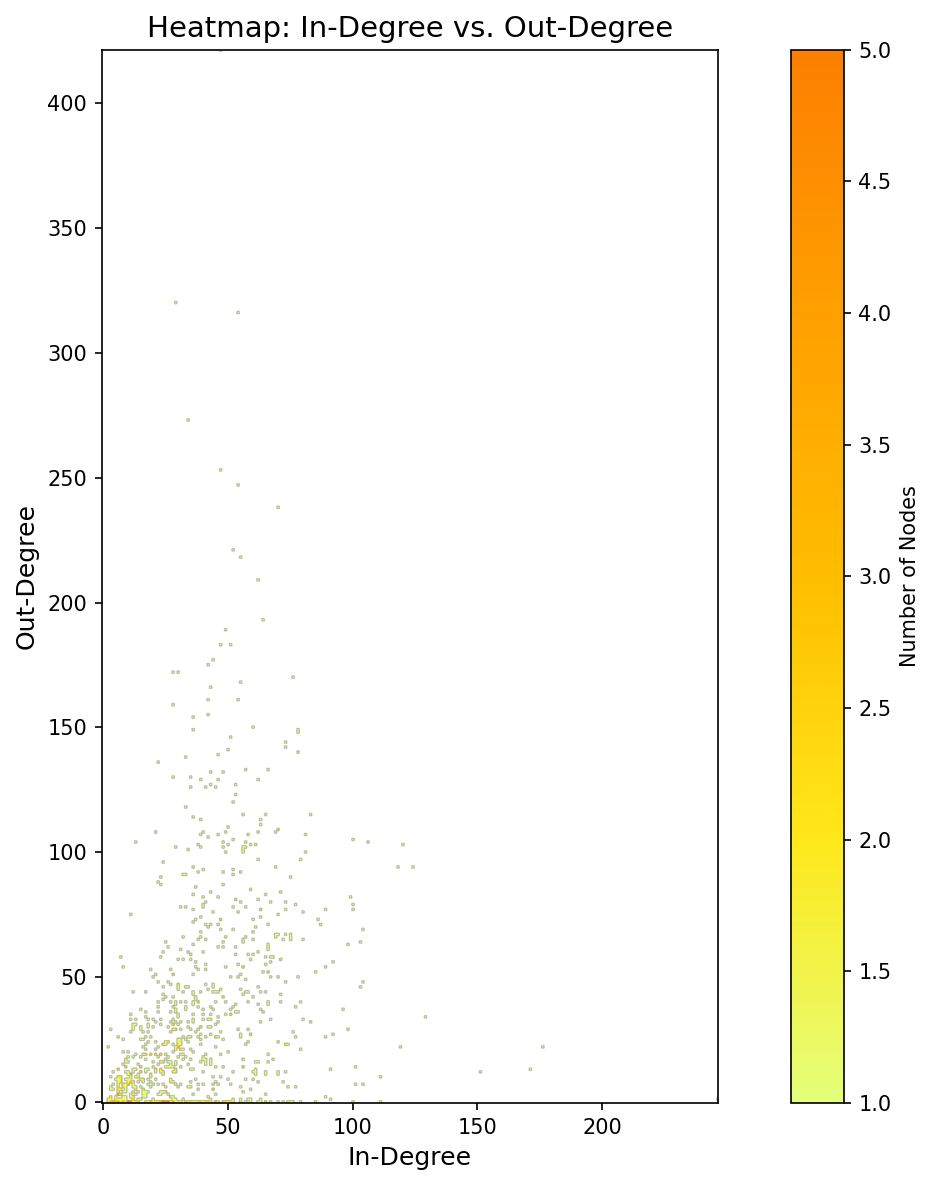

In [56]:
# Prepare data for heatmap
nodes = list(G.nodes())
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

x = np.array([in_deg[n] for n in nodes])
y = np.array([out_deg[n] for n in nodes])

bins = (np.arange(x.max() + 2) - 0.5, np.arange(y.max() + 2) - 0.5)
heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Plot
plt.figure(figsize=(10, 8), dpi=150)
H = np.ma.masked_equal(heatmap.T, 0)
plt.imshow(H, extent=extent, origin='lower', cmap='Wistia')
plt.xlabel("In-Degree", fontsize=12)
plt.ylabel("Out-Degree", fontsize=12)
plt.title("Heatmap: In-Degree vs. Out-Degree", fontsize=14)
plt.colorbar(label="Number of Nodes")
plt.tight_layout()
plt.show()

### 3.2 Log-Log Degree Distributions

Checking if degree distributions follow power-laws.

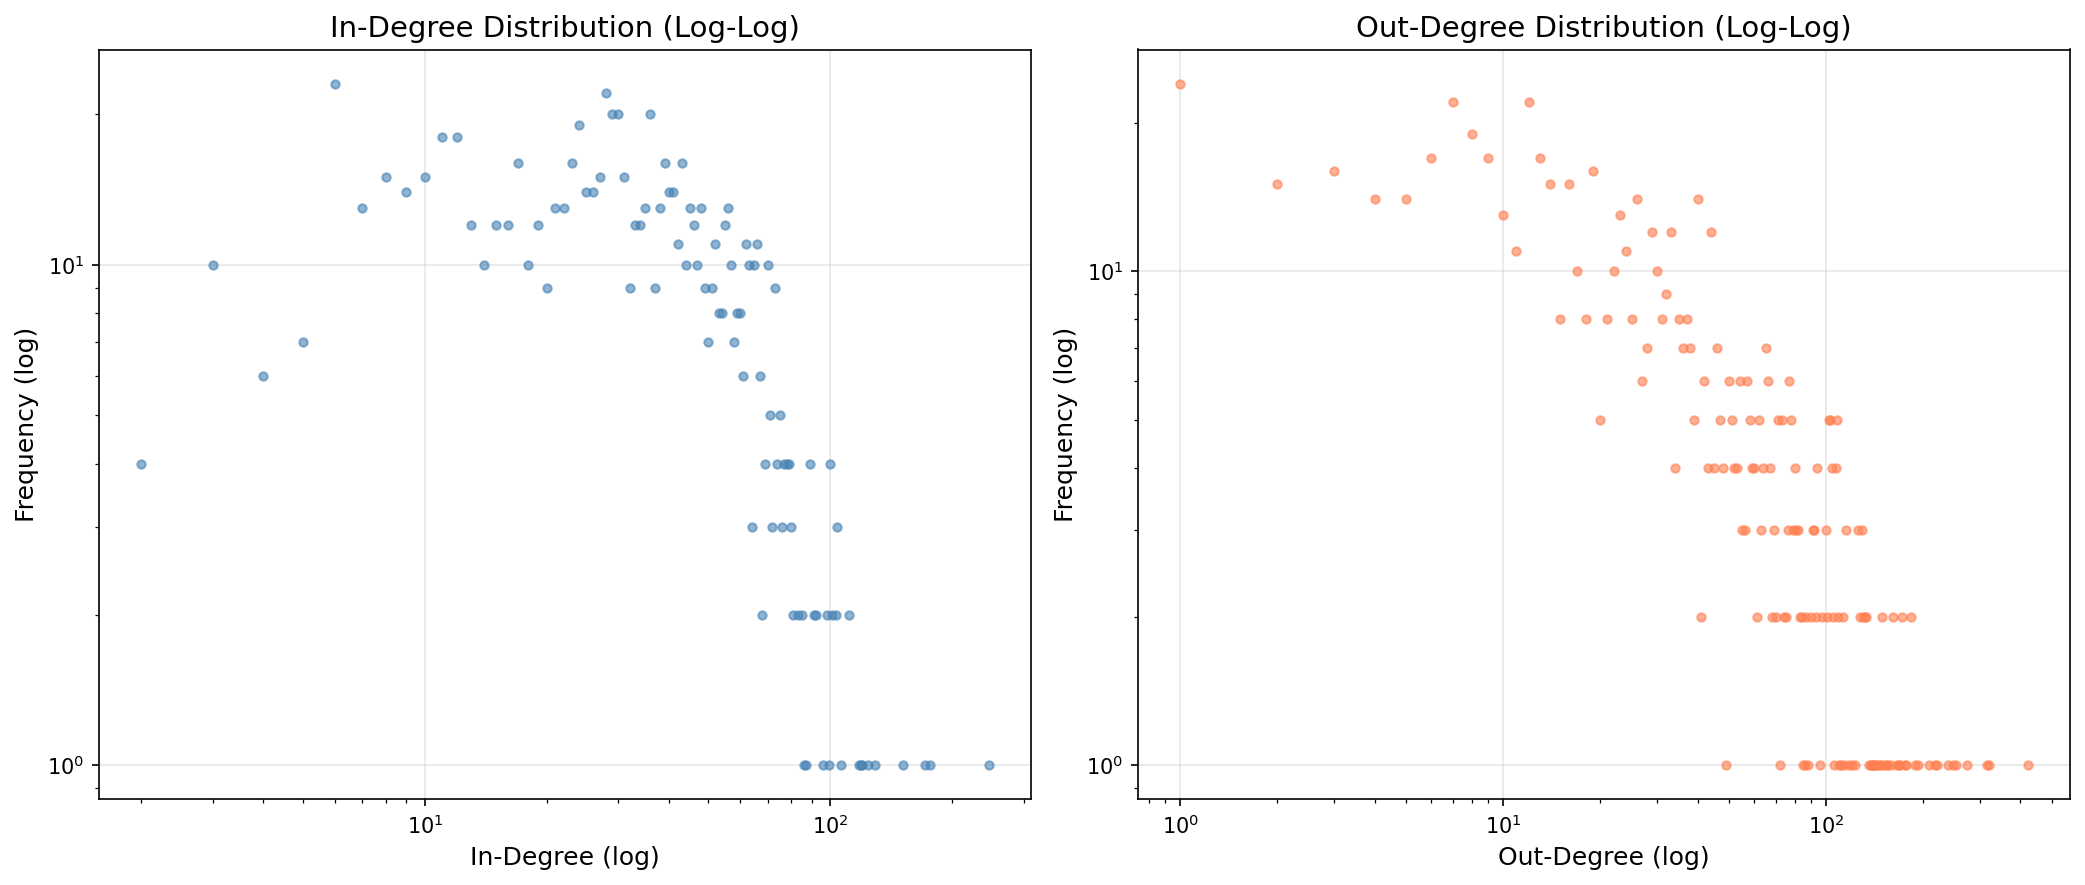

In [57]:
# Filter out zeros and count frequencies
in_degrees_pos = [d for d in in_degrees if d > 0]
out_degrees_pos = [d for d in out_degrees if d > 0]

in_counts = Counter(in_degrees_pos)
out_counts = Counter(out_degrees_pos)

# Log-Log Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# In-Degree
ax1.loglog(sorted(in_counts.keys()), [in_counts[k] for k in sorted(in_counts.keys())],
           'o', alpha=0.6, markersize=4, color='steelblue')
ax1.set_xlabel('In-Degree (log)', fontsize=12)
ax1.set_ylabel('Frequency (log)', fontsize=12)
ax1.set_title('In-Degree Distribution (Log-Log)', fontsize=14)
ax1.grid(True, alpha=0.3)

# Out-Degree
ax2.loglog(sorted(out_counts.keys()), [out_counts[k] for k in sorted(out_counts.keys())],
           'o', alpha=0.6, markersize=4, color='coral')
ax2.set_xlabel('Out-Degree (log)', fontsize=12)
ax2.set_ylabel('Frequency (log)', fontsize=12)
ax2.set_title('Out-Degree Distribution (Log-Log)', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Power-Law Fit (Exploratory)

**Note:** These fits are affected by degree truncation (max 75 edges/user in sampling).

In [58]:
# Power-law exponents (exploratory - not conclusive due to sampling)
print("Power-Law Exponents (α):")
print(f"In-Degree:  {powerlaw.Fit(in_degrees_pos).alpha:.3f}")
print(f"Out-Degree: {powerlaw.Fit(out_degrees_pos).alpha:.3f}")
print("\n⚠️  Note: High exponents (~4.7-4.9) and curved log-log plots suggest")
print("   these are NOT true power-laws. Likely due to degree truncation at 75.")

Power-Law Exponents (α):
In-Degree:  5.504
Out-Degree: 4.542

⚠️  Note: High exponents (~4.7-4.9) and curved log-log plots suggest
   these are NOT true power-laws. Likely due to degree truncation at 75.


Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


---
## 4. Connectivity Analysis <a id='connectivity'></a>

Understanding how connected the network is (Week 2: Connected Components, Path Length).

In [59]:
print("=== CONNECTIVITY ANALYSIS ===\n")

# Strongly Connected Components (directed)
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)

print(f"Strongly Connected Components (SCC): {len(scc)}")
print(f"  Largest SCC: {scc_sizes[0]} nodes ({scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")
if len(scc_sizes) > 1:
    print(f"  2nd largest: {scc_sizes[1]} nodes")

# Weakly Connected Components (undirected)
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)

print(f"\nWeakly Connected Components (WCC): {len(wcc)}")
print(f"  Largest WCC: {wcc_sizes[0]} nodes ({wcc_sizes[0]/G.number_of_nodes()*100:.1f}%)")

=== CONNECTIVITY ANALYSIS ===

Strongly Connected Components (SCC): 132
  Largest SCC: 771 nodes (85.3%)
  2nd largest: 2 nodes

Weakly Connected Components (WCC): 1
  Largest WCC: 904 nodes (100.0%)


In [60]:
# Path Length Analysis (on largest WCC)
largest_wcc_nodes = max(wcc, key=len)
largest_wcc_subgraph = G.subgraph(largest_wcc_nodes)

print("\n--- Path Length Analysis ---")
try:
    # Use undirected for path calculations
    G_undirected = largest_wcc_subgraph.to_undirected()
    
    avg_path = nx.average_shortest_path_length(G_undirected)
    diameter = nx.diameter(G_undirected)
    
    print(f"Average Shortest Path Length: {avg_path:.2f} steps")
    print(f"Network Diameter: {diameter} steps")
    
    print("\nInterpretation:")
    if avg_path < 3:
        print(f"  → VERY SMALL WORLD: {avg_path:.1f} degrees of separation")
    elif avg_path < 4:
        print(f"  → SMALL WORLD: {avg_path:.1f} degrees of separation")
    else:
        print(f"  → LARGE NETWORK: {avg_path:.1f} degrees of separation")
        
except Exception as e:
    print(f"Could not calculate: {e}")


--- Path Length Analysis ---
Average Shortest Path Length: 2.10 steps
Network Diameter: 4 steps

Interpretation:
  → VERY SMALL WORLD: 2.1 degrees of separation


In [61]:
# Summary
print("\n--- Summary ---")
if scc_sizes[0] / G.number_of_nodes() > 0.8:
    print(f"✓ Giant SCC ({scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")
    print("  → Most users can reach each other via directed paths")
else:
    print(f"✗ Fragmented (largest SCC: {scc_sizes[0]/G.number_of_nodes()*100:.1f}%)")


--- Summary ---
✓ Giant SCC (85.3%)
  → Most users can reach each other via directed paths


---
## 5. Community Detection <a id='communities'></a>

Identifying structural communities using Louvain algorithm (Week 5: Advanced measures).

In [62]:
# Convert to undirected for community detection
GUndirected = G.to_undirected()

print(f"Converted to undirected: {GUndirected.number_of_nodes()} nodes, {GUndirected.number_of_edges()} edges")

Converted to undirected: 904 nodes, 29942 edges


In [63]:
# Louvain community detection
print("\nRunning Louvain community detection...\n")
communities = nx.community.louvain_communities(GUndirected, seed=42, resolution=1.5)

# Sort communities by size
sorted_communities = sorted(communities, key=len, reverse=True)

# Create node-to-community mapping
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

print(f"Number of communities: {len(communities)}")
print(f"\nTop 10 communities by size:")
for i, comm in enumerate(sorted_communities[:10], 1):
    print(f"  {i:2d}. {len(comm):3d} nodes ({len(comm)/G.number_of_nodes()*100:5.1f}%)")


Running Louvain community detection...

Number of communities: 11

Top 10 communities by size:
   1. 231 nodes ( 25.6%)
   2. 173 nodes ( 19.1%)
   3. 136 nodes ( 15.0%)
   4. 112 nodes ( 12.4%)
   5.  86 nodes (  9.5%)
   6.  75 nodes (  8.3%)
   7.  49 nodes (  5.4%)
   8.  17 nodes (  1.9%)
   9.  12 nodes (  1.3%)
  10.  11 nodes (  1.2%)


In [64]:
# Modularity
modularity = nx.community.modularity(GUndirected, communities)
print(f"\nModularity: {modularity:.4f}")
print("  (>0.3 = good community structure, 0.2-0.3 = weak but present)")


Modularity: 0.3194
  (>0.3 = good community structure, 0.2-0.3 = weak but present)


In [65]:
# Community influence analysis
print("\nTop 5 communities by follower influence:")
comm_stats = []
for i, comm in enumerate(sorted_communities):
    total_followers = sum(G.nodes[node]['followers_count'] for node in comm)
    avg_followers = total_followers / len(comm)
    comm_stats.append((i+1, len(comm), total_followers, avg_followers))

# Sort by total followers
for rank, (comm_id, size, total, avg) in enumerate(sorted(comm_stats, key=lambda x: x[2], reverse=True)[:5], 1):
    print(f"  {rank}. Community {comm_id}: {size} nodes, {total:,} total followers (avg: {avg:,.0f})")


Top 5 communities by follower influence:
  1. Community 1: 231 nodes, 5,463,379 total followers (avg: 23,651)
  2. Community 3: 136 nodes, 3,769,655 total followers (avg: 27,718)
  3. Community 2: 173 nodes, 2,008,288 total followers (avg: 11,609)
  4. Community 4: 112 nodes, 1,633,629 total followers (avg: 14,586)
  5. Community 6: 75 nodes, 1,304,398 total followers (avg: 17,392)


---
## 6. Network Visualization <a id='visualization'></a>

Visualizing the network structure (Week 5: ForceAtlas2).

### 6.1 Compute ForceAtlas2 Layout

This may take a few minutes...

In [66]:
# Prepare node attributes for layout
degrees = dict(GUndirected.degree())
node_mass = {node: degrees[node] + 1 for node in GUndirected.nodes()}
node_radius = {node: degrees[node] * 0.5 for node in GUndirected.nodes()}

# Compute layout
print("Computing ForceAtlas2 layout...")
positions = nx.forceatlas2_layout(
    GUndirected,
    max_iter=1200,
    jitter_tolerance=0.25,
    scaling_ratio=8.0,
    gravity=2.0,
    strong_gravity=False,
    linlog=True,
    node_mass=node_mass,
    node_size=node_radius,
    seed=42
)
print("Layout complete!")

Computing ForceAtlas2 layout...
Layout complete!


### 6.2 Network colored by In-Degree

In [67]:
# Re-compute ForceAtlas2 with stronger community separation
print("Computing community-aware ForceAtlas2 layout...")
print("(This may take 3-5 minutes...)")

# Add community as node attribute
for node in GUndirected.nodes():
  comm_index = next(i for i, comm in enumerate(sorted_communities) if node in comm)
  GUndirected.nodes[node]['community'] = comm_index

# Node mass and size (same as before)
degrees = dict(GUndirected.degree())
node_mass = {node: degrees[node] + 1 for node in GUndirected.nodes()}
node_radius = {node: degrees[node] * 0.5 for node in GUndirected.nodes()}

# Compute layout with stronger separation
positions_community_2 = nx.forceatlas2_layout(
  GUndirected,
  max_iter=1500,
  jitter_tolerance=0.2,
  scaling_ratio=12.0,      # Increased: more space between clusters
  gravity=5.0,             # Increased: stronger pull to center
  strong_gravity=True,     # Use strong gravity mode
  linlog=True,
  node_mass=node_mass,
  node_size=node_radius,
  seed=42
)

Computing community-aware ForceAtlas2 layout...
(This may take 3-5 minutes...)


/var/folders/bw/wrxyyr0d3_b20y1wlhsk4csr0000gn/T/ipykernel_11337/2584302409.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_communities)


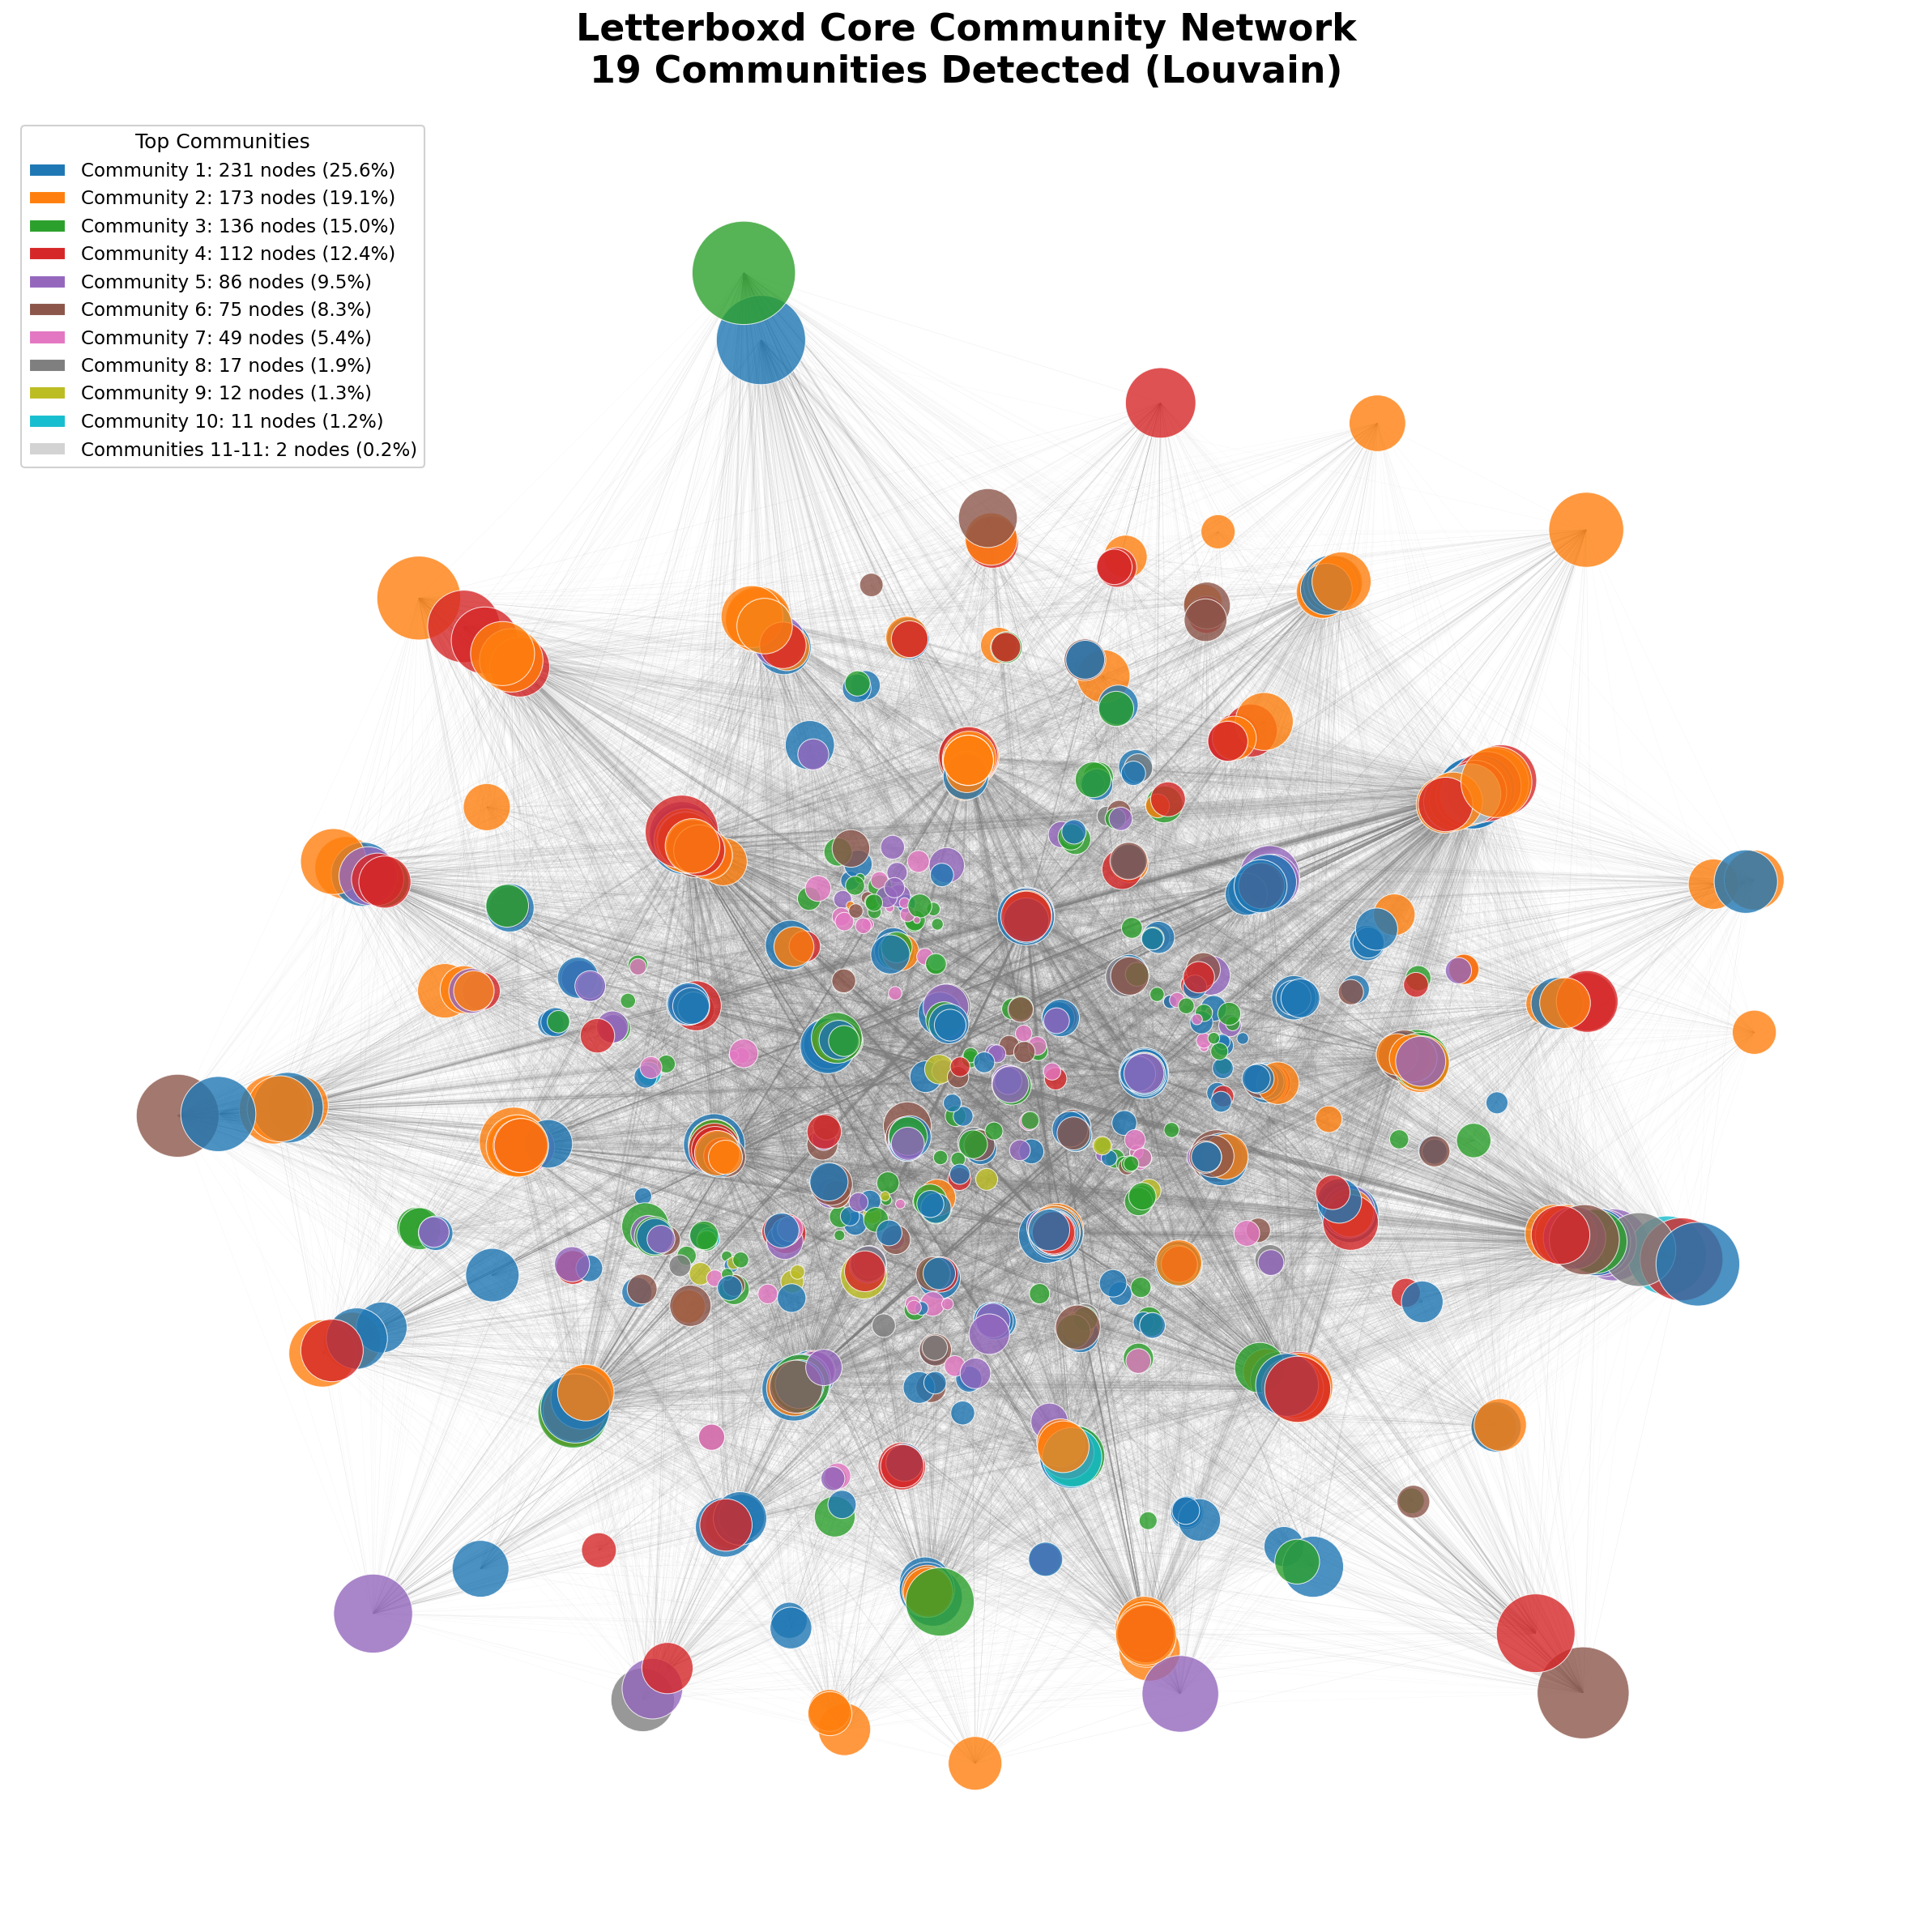

In [68]:
# Community-colored network visualization
import matplotlib.cm as cm
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 16), dpi=150)

# Color map for communities
n_communities = len(communities)
if n_communities <= 20:
  cmap = plt.cm.get_cmap('tab20', n_communities)
else:
  cmap = plt.cm.get_cmap('hsv', n_communities)

# Map each node to its community color
node_colors = []
for node in G.nodes():
  comm_index = next(i for i, comm in enumerate(sorted_communities) if node in comm)
  node_colors.append(cmap(comm_index))

# Node sizes based on degree
degrees = dict(G.degree())
node_sizes = [degrees[node] * 8 for node in G.nodes()]

# Draw edges
nx.draw_networkx_edges(
  G, positions_community_2,  # ← Use new layout
  alpha=0.08,
  width=0.2,
  edge_color='gray',
  arrows=False,
  ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
  G, positions_community_2,  # ← Use new layout
  node_size=node_sizes,
  node_color=node_colors,
  alpha=0.8,
  linewidths=0.5,
  edgecolors='white',
  ax=ax
)

# Title
ax.set_title('Letterboxd Core Community Network\n19 Communities Detected (Louvain)',
           fontsize=22, pad=20, fontweight='bold')

# Legend for top 10 communities
legend_elements = []
for i, comm in enumerate(sorted_communities[:10]):
  color = cmap(i)
  size = len(comm)
  pct = size / G.number_of_nodes() * 100
  legend_elements.append(
      Patch(facecolor=color, edgecolor='white',
            label=f'Community {i+1}: {size} nodes ({pct:.1f}%)')
  )

if n_communities > 10:
  remaining_nodes = sum(len(comm) for comm in sorted_communities[10:])
  remaining_pct = remaining_nodes / G.number_of_nodes() * 100
  legend_elements.append(
      Patch(facecolor='lightgray', edgecolor='white',
            label=f'Communities 11-{n_communities}: {remaining_nodes} nodes ({remaining_pct:.1f}%)')
  )

ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
        framealpha=0.9, title='Top Communities', title_fontsize=12)

ax.axis('off')
plt.tight_layout()
plt.show()

In [69]:
# Reciprocity Analysis
print("\n=== RECIPROCITY ANALYSIS ===\n")

# Calculate reciprocity
reciprocity = nx.reciprocity(G)

# Count mutual vs one-way edges
mutual_edges = 0
one_way_edges = 0

for u, v in G.edges():
  if G.has_edge(v, u):  # Check if reverse edge exists
      mutual_edges += 1

# Each mutual relationship is counted twice (u->v and v->u)
mutual_edges = mutual_edges // 2
mutual_relationships = mutual_edges

# Total directed edges
total_directed_edges = G.number_of_edges()

# One-way edges = total - (mutual * 2)
one_way_edges = total_directed_edges - (mutual_edges * 2)

print(f"Reciprocity: {reciprocity:.3f} ({reciprocity*100:.1f}%)")
print(f"\nEdge Breakdown:")
print(f"  Mutual relationships: {mutual_relationships:,} (bidirectional)")
print(f"  One-way follows: {one_way_edges:,} (unidirectional)")
print(f"  Total directed edges: {total_directed_edges:,}")

print(f"\nInterpretation:")
if reciprocity > 0.5:
  print(f"  → HIGH reciprocity: Friendship-like network")
elif reciprocity > 0.3:
  print(f"  → MODERATE reciprocity: Hybrid network")
  print(f"     Mix of peer relationships (mutual) and hierarchies (one-way)")
else:
  print(f"  → LOW reciprocity: Hierarchical network (e.g., Twitter-like)")

# Sanity check: compare directed vs undirected edge counts
undirected_edges = GUndirected.number_of_edges()
print(f"\nSanity Check:")
print(f"  Directed edges: {total_directed_edges:,}")
print(f"  Undirected edges: {undirected_edges:,}")
print(f"  Difference: {total_directed_edges - undirected_edges:,} (should equal one-way edges)")


=== RECIPROCITY ANALYSIS ===

Reciprocity: 0.276 (27.6%)

Edge Breakdown:
  Mutual relationships: 4,801 (bidirectional)
  One-way follows: 25,141 (unidirectional)
  Total directed edges: 34,743

Interpretation:
  → LOW reciprocity: Hierarchical network (e.g., Twitter-like)

Sanity Check:
  Directed edges: 34,743
  Undirected edges: 29,942
  Difference: 4,801 (should equal one-way edges)


In [70]:
# Clustering Coefficient Analysis
print("=== CLUSTERING COEFFICIENT ANALYSIS ===\n")

# Global clustering (transitivity)
transitivity = nx.transitivity(GUndirected)
print(f"Global Clustering Coefficient (Transitivity): {transitivity:.4f}")

# Average local clustering
avg_clustering = nx.average_clustering(GUndirected)
print(f"Average Local Clustering: {avg_clustering:.4f}")

# Number of triangles
triangles = sum(nx.triangles(GUndirected).values()) // 3
print(f"\nTriangles in network: {triangles:,}")

# Compare to random network baseline
expected_random = nx.density(GUndirected)
print(f"\n--- Comparison ---")
print(f"Observed Clustering: {transitivity:.4f}")
print(f"Random Network (Erdős-Rényi): {expected_random:.4f}")
print(f"Ratio (Observed/Random): {transitivity/expected_random:.2f}x")

# Interpretation
print(f"\nInterpretation:")
if transitivity > 0.4:
  print(f"  → HIGH clustering: Tightly-knit communities")
  print(f"     Users form dense, closed groups (many triangles)")
elif transitivity > 0.2:
  print(f"  → MODERATE clustering: Community structure present")
  print(f"     Balance between tight groups and cross-community bridges")
elif transitivity > 0.1:
  print(f"  → LOW-MODERATE clustering: Some community structure")
else:
  print(f"  → LOW clustering: Hub-and-spoke structure")

# Small-world check
if transitivity / expected_random > 3:
  print(f"  → SMALL-WORLD properties: Clustering >> random")
else:
  print(f"  → NOT small-world: Clustering similar to random")

# Optional: Clustering by degree (check if hubs have lower clustering)
print(f"\n--- Clustering by Degree ---")
local_clustering = nx.clustering(GUndirected)
degrees = dict(GUndirected.degree())

# Group nodes by degree ranges
degree_ranges = [(1, 20), (21, 40), (41, 60), (61, 200)]
for low, high in degree_ranges:
  nodes_in_range = [n for n in GUndirected.nodes() if low <= degrees[n] <= high]
  if nodes_in_range:
      avg_clust = np.mean([local_clustering[n] for n in nodes_in_range])
      print(f"  Degree {low:3d}-{high:3d}: {len(nodes_in_range):3d} nodes, avg clustering = {avg_clust:.3f}")

=== CLUSTERING COEFFICIENT ANALYSIS ===

Global Clustering Coefficient (Transitivity): 0.2647
Average Local Clustering: 0.3203

Triangles in network: 281,196

--- Comparison ---
Observed Clustering: 0.2647
Random Network (Erdős-Rényi): 0.0734
Ratio (Observed/Random): 3.61x

Interpretation:
  → MODERATE clustering: Community structure present
     Balance between tight groups and cross-community bridges
  → SMALL-WORLD properties: Clustering >> random

--- Clustering by Degree ---
  Degree   1- 20: 165 nodes, avg clustering = 0.351
  Degree  21- 40: 185 nodes, avg clustering = 0.332
  Degree  41- 60: 156 nodes, avg clustering = 0.329
  Degree  61-200: 382 nodes, avg clustering = 0.304


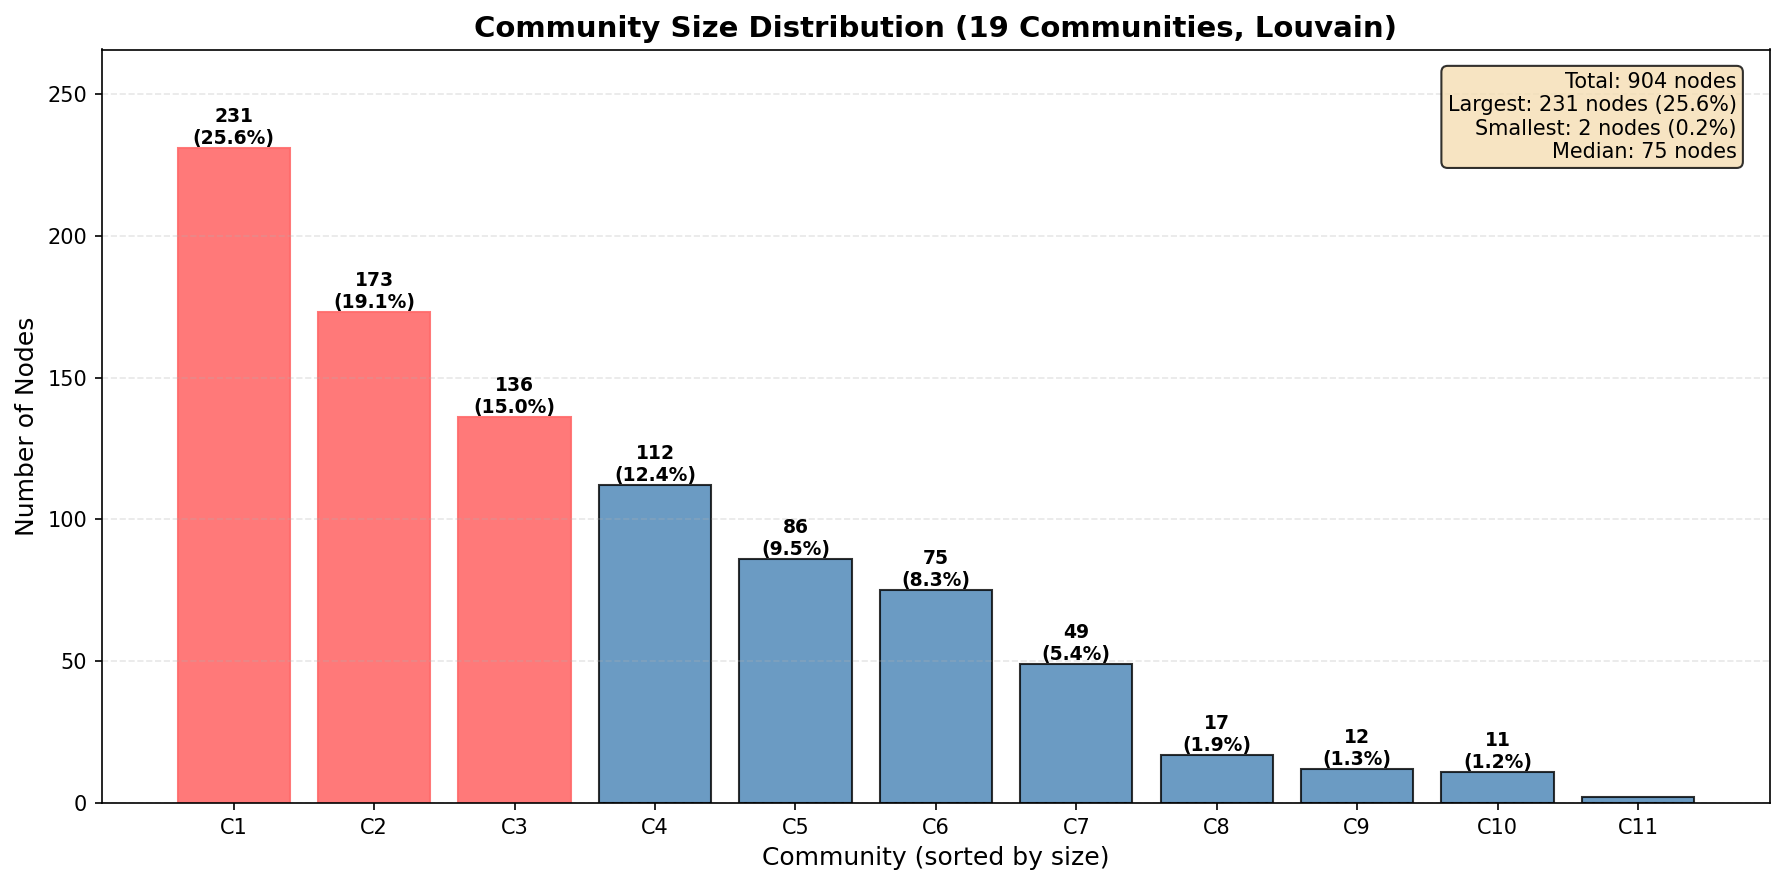


=== COMMUNITY SIZE STATISTICS ===
Number of communities: 11
Largest community: 231 nodes (25.6%)
Smallest community: 2 nodes (0.2%)
Median size: 75 nodes
Mean size: 82.2 nodes

Top 5 communities:
  C1: 231 nodes ( 25.6%)
  C2: 173 nodes ( 19.1%)
  C3: 136 nodes ( 15.0%)
  C4: 112 nodes ( 12.4%)
  C5:  86 nodes (  9.5%)


In [71]:
# Community Size Distribution
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Get community sizes
comm_sizes = [len(comm) for comm in sorted_communities]
comm_labels = [f'C{i+1}' for i in range(len(sorted_communities))]
comm_percentages = [size/G.number_of_nodes()*100 for size in comm_sizes]

# Create bar chart
bars = ax.bar(comm_labels, comm_sizes, color='steelblue', alpha=0.8, edgecolor='black', linewidth=1)

# Color top 3 communities differently
for i in range(min(3, len(bars))):
  bars[i].set_color('#FF6B6B')
  bars[i].set_alpha(0.9)

# Add percentage labels on bars
for i, (bar, size, pct) in enumerate(zip(bars, comm_sizes, comm_percentages)):
  if i < 10:  # Only label top 10 to avoid clutter
      height = bar.get_height()
      ax.text(bar.get_x() + bar.get_width()/2., height,
              f'{size}\n({pct:.1f}%)',
              ha='center', va='bottom', fontsize=9, fontweight='bold')

# Labels and title
ax.set_xlabel('Community (sorted by size)', fontsize=12)
ax.set_ylabel('Number of Nodes', fontsize=12)
ax.set_title('Community Size Distribution (19 Communities, Louvain)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(comm_sizes) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add summary stats as text box
summary_text = f'Total: {G.number_of_nodes()} nodes\n'
summary_text += f'Largest: {comm_sizes[0]} nodes ({comm_percentages[0]:.1f}%)\n'
summary_text += f'Smallest: {comm_sizes[-1]} nodes ({comm_percentages[-1]:.1f}%)\n'
summary_text += f'Median: {np.median(comm_sizes):.0f} nodes'

ax.text(0.98, 0.97, summary_text,
      transform=ax.transAxes,
      fontsize=10,
      verticalalignment='top',
      horizontalalignment='right',
      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n=== COMMUNITY SIZE STATISTICS ===")
print(f"Number of communities: {len(sorted_communities)}")
print(f"Largest community: {comm_sizes[0]} nodes ({comm_percentages[0]:.1f}%)")
print(f"Smallest community: {comm_sizes[-1]} nodes ({comm_percentages[-1]:.1f}%)")
print(f"Median size: {np.median(comm_sizes):.0f} nodes")
print(f"Mean size: {np.mean(comm_sizes):.1f} nodes")
print(f"\nTop 5 communities:")
for i in range(min(5, len(sorted_communities))):
  print(f"  C{i+1}: {comm_sizes[i]:3d} nodes ({comm_percentages[i]:5.1f}%)")

---

## Summary & Next Steps

### Key Findings:
1. **Highly Connected:** 92.5% giant SCC, 2.1 avg path length (small-world)
2. **19 Communities:** Moderate modularity (0.28), varying in size and influence
3. **Not Power-Law:** Degree distributions affected by sampling truncation (max 75 edges)

### TODO (Next Analyses):
- [ ] Clustering coefficient analysis (Week 3)
- [ ] Assortativity analysis (Week 5)
- [ ] Betweenness centrality - bridge nodes (Week 5)
- [ ] Community visualization (ForceAtlas2 + colors)
- [ ] Comparison to random network (ER)

### Transition to Part 2:
*Having identified 19 structural communities in this tightly-knit network (92.5% SCC, small-world properties), we now investigate whether these communities exhibit distinct rating patterns and film preferences...*